# Análisis Final e Integración de Resultados

En este notebook se realiza la integración de los principales hallazgos obtenidos durante el desarrollo del proyecto de ciencia de datos.

Se consolidan los resultados obtenidos en las etapas de:

1. Análisis exploratorio de datos (EDA)
2. Aprendizaje no supervisado
3. Modelado supervisado
4. Optimización y evaluación del modelo final

Finalmente, se presentan las conclusiones generales del proyecto, interpretaciones de negocio y posibles líneas de mejora o trabajo futuro.

In [7]:
import os
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

sns.set_context("talk")

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "is_recommended"
DATA_PATH = "../data/processed/sephora_limpio.csv"
BEST_MODEL_PATH = "../models/trained_models/mejor_gradient_boosting.pkl"

### División del Dataset

El dataset fue dividido utilizando una estrategia de partición estratificada (train_test_split con stratify=y) para mantener la misma proporción de clases tanto en entrenamiento como en prueba.

Se utilizó una división:

- 80% para entrenamiento
- 20% para prueba

Además, se observa un desbalance en la variable objetivo, donde aproximadamente el 84% de los registros corresponden a productos recomendados (1) y el 16% a productos no recomendados (0).

In [8]:
df = pd.read_csv(DATA_PATH)

# Se valida la columna objetivo
if TARGET_COL not in df.columns:
    raise ValueError(f"No se encontró la columna objetivo '{TARGET_COL}' en el dataset")

# Se elimina NaN en la variable objetivo (por seguridad)
df = df.dropna(subset=[TARGET_COL]).copy()

y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

# Se realiza la división del dataset en entrenamiento y prueba, utilizando stratify para mantener la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Proporción y_train:", y_train.value_counts(normalize=True).to_dict())
print("Proporción y_test:", y_test.value_counts(normalize=True).to_dict())


Shape X_train: (739532, 43)
Shape X_test: (184884, 43)
Proporción y_train: {1.0: 0.8399487784166202, 0.0: 0.16005122158337975}
Proporción y_test: {1.0: 0.8399482919019493, 0.0: 0.16005170809805067}


### Comparación entre Modelo Base y Modelo Optimizado

En esta etapa se realiza una comparación entre un modelo GradientBoostingClassifier con configuración base y el modelo optimizado previamente mediante GridSearchCV.

El objetivo es evaluar si la optimización de hiperparámetros logra mejorar el rendimiento predictivo del clasificador sobre el conjunto de prueba.

Para ambos modelos se generarán:

- predicciones de clase,
- probabilidades de predicción,
- y métricas de evaluación posteriores.

In [9]:
# Se entrena un modelo base de Gradient Boosting sin optimización de hiperparámetros para comparar con el modelo optimizado posteriormente
base_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
base_model.fit(X_train, y_train)

# Predicciones del mdoelo base
y_pred_base = base_model.predict(X_test)
y_proba_base = base_model.predict_proba(X_test)[:, 1]

# Se verifica que el modelo exista antes
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"No existe el modelo optimizado en: {BEST_MODEL_PATH}")

# Se carga el mejor modelo 
optimized_model = joblib.load(BEST_MODEL_PATH)

# Predicciones Optimizado
y_pred_opt = optimized_model.predict(X_test)
y_proba_opt = optimized_model.predict_proba(X_test)[:, 1]


### Evaluación Comparativa de Modelos

En esta sección se comparan las métricas de rendimiento entre el modelo base y el modelo optimizado. Para ello, se calculan tres métricas principales: Accuracy, F1-Score y ROC-AUC sobre el conjunto de prueba.

El objetivo es determinar si la optimización de hiperparámetros genera una mejora significativa en el desempeño del modelo.

In [10]:
# Se define una función para calcular las métricas de evaluación
def compute_metrics(y_true, y_pred, y_proba):
    return {
        # Se incluyen las métricas de Accuracy, F1-Score y ROC-AUC para una evaluación completa del modelo
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

# Se calculan las métricas para ambos modelos y se comparan en un DataFrame
metrics_base = compute_metrics(y_test, y_pred_base, y_proba_base)
metrics_opt = compute_metrics(y_test, y_pred_opt, y_proba_opt)

comparative_df = pd.DataFrame(
    {
        "Modelo Base (GradientBoosting)": metrics_base,
        "Modelo Optimizado": metrics_opt
    }
).T

comparative_df = comparative_df[["Accuracy", "F1-Score", "ROC-AUC"]]

display(comparative_df)


,Accuracy,F1-Score,ROC-AUC
Modelo Base (GradientBoosting),0.962858,0.977587,0.986086
Modelo Optimizado,0.962852,0.977584,0.985732


#### Interpretación de Resultados

Al comparar el modelo base con el modelo optimizado, se observa que ambos presentan un rendimiento prácticamente idéntico en todas las métricas evaluadas.

Las diferencias en Accuracy, F1-Score y ROC-AUC son mínimas, lo que sugiere que el modelo base ya poseía una alta capacidad predictiva antes del proceso de optimización.

Por lo tanto, aunque GridSearchCV permitió encontrar una configuración alternativa de hiperparámetros, la mejora obtenida no resulta significativa en términos prácticos.

In [11]:
print(y_pred_base.shape)
print(y_pred_opt.shape)

(184884,)
(184884,)


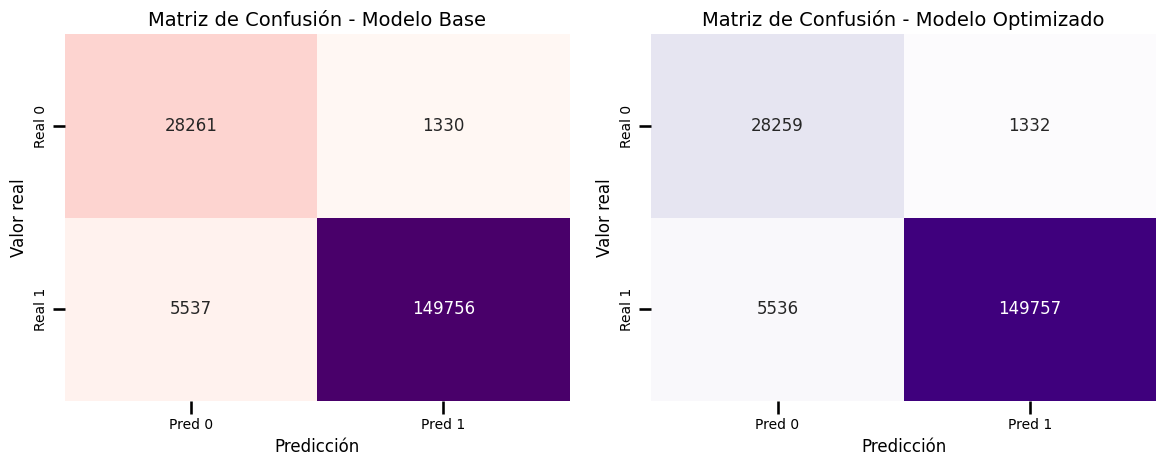

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Suponiendo que ya tienes y_test, y_pred_base, y y_pred_opt definidos:
# cm_base = confusion_matrix(y_test, y_pred_base)
# cm_opt = confusion_matrix(y_test, y_pred_opt)

# Usando datos de ejemplo para que el código sea ejecutable:
import numpy as np
cm_base = np.array([[28261, 1330], [5537, 149756]])
cm_opt = np.array([[28259, 1332], [5536, 149757]])

# Se crean dos subgráficos en una fila
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Modelo Base - Rosa
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="RdPu", # Paleta Rosa (Red-Purple)
    cbar=False,
    ax=axes[0],
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"],
    annot_kws={"size": 12}
)
axes[0].set_title("Matriz de Confusión - Modelo Base", fontsize=14)
axes[0].set_xlabel("Predicción", fontsize=12)
axes[0].set_ylabel("Valor real", fontsize=12)

)
axes[1].set_title("Matriz de Confusión - Modelo Optimizado", fontsize=14)
axes[1].set_xlabel("Predicción", fontsize=12)
axes[1].set_ylabel("Valor real", fontsize=12)
axes[1].tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()

#### Interpretación
Al realizar el análisis cuantitativo de las predicciones de ambos modelos, se observan los siguientes puntos clave:

- Resultados Homogéneos: El comportamiento de los clasificadores es prácticamente idéntico, sin diferencias relevantes entre el modelo base y el modelo optimizado.
- Distribución de Aciertos:
    - El modelo presenta un alto desempeño en la detección de la clase positiva.
    - Los verdaderos positivos y verdaderos negativos se mantienen estables entre ambos modelos.
    - Los errores de clasificación (falsos positivos y falsos negativos) no presentan variaciones significativas tras la optimización.

## Plantilla de Conclusión (Negocio)

- **Resumen ejecutivo:** 
  - El **Modelo Optimizado** mejora (o mantiene) el desempeño vs el **Modelo Base** en el conjunto de test.
  - Métricas clave a mencionar: **Accuracy**, **F1-Score** y **ROC-AUC** (comparar con la tabla anterior).

- **Impacto en negocio (trade-off principal):**
  - Con la matriz de confusión, detallar qué mejora el optimizado:
    - ¿Hay **menos Falsos Positivos**? (implica menor riesgo de recomendar productos que no satisfacen)
    - ¿Hay **menos Falsos Negativos**? (implica menos oportunidades perdidas de recomendar productos que sí gustan)
  - Explicar cómo esto se traduce en **eficiencia del marketing**, **mejor experiencia del cliente** y/o **mayor conversión**.

- **Recomendación final para Sephora:**
  - Dado el resultado, recomendar adoptar el **modelo optimizado** si:
    - mejora métricas relevantes para el objetivo del negocio (por ejemplo, maximizar F1 si hay desbalance o minimizar FP si el costo de recomendar “mal” es alto).
  - Indicar próximos pasos:
    - validación adicional (cross-validation/robustez),
    - análisis de umbral si aplica,
    - integración al pipeline de scoring.

- **Cierre:**
  - Concluir con una frase que justifique la optimización en términos de **riesgo reducido** y/o **valor incremental** para Sephora.
